# Macro

### Create Hexagon

In [ ]:
import pandas as pd

dataA1 = pd.read_csv('../ComputedData/Accident/DataA1_with_MRT_Youbike_Parkinglot.csv')
dataA2 = pd.read_csv('../ComputedData/Accident/DataA2_with_MRT_Youbike_Parkinglot.csv')

dataA1.head()

In [7]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Polygon

In [ ]:
def create_hexagon(center_x, center_y, size):
    angles = np.linspace(0, 2 * np.pi, 7)
    return Polygon([
        (center_x + size * np.cos(angle), center_y + size * np.sin(angle))
        for angle in angles
    ])

In [27]:
gdf = gpd.GeoDataFrame(dataA1, geometry=gpd.points_from_xy(dataA1.經度, dataA1.緯度))

gdf = gdf[
    (gdf['經度'] >= 119.7) & (gdf['經度'] <= 122.1) &
    (gdf['緯度'] >= 21.8) & (gdf['緯度'] <= 25.4)
]

# Step 2: 計算範圍 (bounding box)
bounds = gdf.total_bounds  # (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = bounds

# hexagon 大小 (degree)
hex_size = 0.05  # 度數，大概10km（視緯度而定）

# 六邊形的寬度和高度
width = hex_size * 2
height = np.sqrt(3) * hex_size

# 計算橫向和縱向的hexagon間距
x_spacing = width * 3/4
y_spacing = height

In [29]:
# hexagon grid
hexagons = []
x_start = minx
y_start = miny

x_end = maxx
y_end = maxy

x = x_start
while x < x_end + width:
    y = y_start
    while y < y_end + height:
        hex_center = (x, y)
        hexagon = create_hexagon(*hex_center, hex_size)
        hexagons.append(hexagon)
        y += y_spacing
    x += x_spacing

# 每列交錯排列，蜂巢狀
hexagons_shifted = []
row = 0
x = x_start
while x < x_end + width:
    y = y_start + (y_spacing / 2 if row % 2 else 0) 
    while y < y_end + height:
        hex_center = (x, y)
        hexagon = create_hexagon(*hex_center, hex_size)
        hexagons_shifted.append(hexagon)
        y += y_spacing
    x += x_spacing
    row += 1

hex_grid = gpd.GeoDataFrame(geometry=hexagons_shifted, crs='EPSG:4326')

<Axes: >

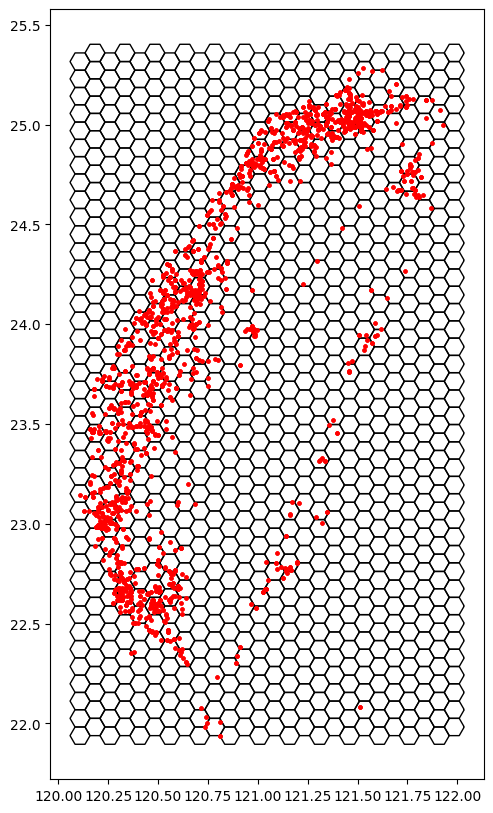

In [38]:
ax = hex_grid.plot(edgecolor='k', facecolor='none', figsize=(10, 10))
gdf.plot(ax=ax, color='red', markersize=5)

### Morans I
使用 Incremental Spatial Autocorrelation (ISA)

### GI